In [1]:
import tensorflow as tf
import numpy as np
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import matplotlib.pyplot as plt
from keras.models import load_model
plt.rcParams.update({'font.size': 16})
import time
import numpy as np
from hilbert import decode, encode
import keras
from tf_fourier_features import FourierFeatureProjection

from numpy import loadtxt
import tensorflow as tf
import numpy as np
from scipy.stats.qmc import Sobol
plt.rcParams.update({'font.size': 18})
import matplotlib as mpl
import matplotlib.ticker as ticker
import os
from PIL import Image


In [2]:
from distutils.version import LooseVersion
import skopt


In [3]:
rs = lambda x:tf.reshape(tf.convert_to_tensor(x,dtype=dtype),(-1,1))
rs2 = lambda x:tf.reshape(tf.convert_to_tensor(x,dtype=dtype),(-1,2))
sin = lambda x:tf.math.sin(x)
cos = lambda x:tf.math.cos(x)
abs = lambda x:tf.math.abs(x)
mse = lambda x:tf.reduce_mean(tf.square(x))


In [4]:
class SimulationConfig:
    def __init__(self):
        # -------------------------------------------------------
        # Base constants and ranges
        # -------------------------------------------------------
        self.dtype = 'float32'
        self.xmin, self.ymin = 0.0, 0.0
        self.xmax, self.ymax = 1.0, 1.0
        self.tmin, self.tmax = 0.0, 1.0

        # Geometry
        self.X = 0.25
        self.Y = 0.25
        self.T_ = 300#3600.0*2

        # Model parameters
        self.kappa = 1.0
        self.kappas = 0.1
        self.kappaa = self.kappa - self.kappas
        self.A = 0.1


        # Radiation constants
        self.sigma = 5.67036713e-8
        self.thetas = 1000
        self.n = 1.4

        # Two-material case parameters
        self.k1 = 0.35
        self.k2 = 237.0
        self.rho1 = 1900.0
        self.rho2 = 2700.0
        self.cv1 = 1000.0
        self.cv2 = 900.0

        # Additional parameters
        self.gmin = 0.0001
        self.gmax = 0.5
        self.theta0 = 1.0
        self.thetabc = 0.3
        self.thetad = 0.5

        self.Bi = lambda h, k: h * self.X / k

        self.alpha = self.X * self.kappaa
        self.nn = 4 * self.n**2

        self.d = self.X / self.Y
        self.S = self.X**(-1) / (3 * self.kappa - self.A * self.kappas)

        # Material 1 and 2
        self.chi1 = self.k1 / (self.rho1 * self.cv1)
        self.chi2 = self.k2 / (self.rho2 * self.cv2)
        self.Fo1 = self.T_ * self.chi1 / self.X**2
        self.Fo2 = self.T_ * self.chi2 / self.X**2
        self.Bir = self.sigma * self.thetas**3 * self.X# / self.k1


        self.N_0 = 8000
        self.N_b = 8000
        self.N_r = 60000#40000    
        self.N_tmp = 20
        self.ex = 0.01

        self.xlist = np.linspace(0, 1, 10)
    
    # -----------------------------------------------------------
    def summary(self):
        """Print important values."""
        print("chi1:", self.chi1)
        print("chi2:", self.chi2)
        print("Fo1:", self.Fo1)
        print("Fo2:", self.Fo2)
        print("Bir:", self.Bir)
        print("alpha:", self.alpha)
        print("nn:", self.nn)
        print("d:", self.d)
        print("S:", self.S)

In [5]:
cfg = SimulationConfig()
cfg.summary()

chi1: 1.8421052631578946e-07
chi2: 9.753086419753086e-05
Fo1: 0.0008842105263157894
Fo2: 0.46814814814814815
Bir: 14.175917824999999
alpha: 0.225
nn: 7.839999999999999
d: 1.0
S: 1.3377926421404682


In [6]:
cfg.Fo1*cfg.Bir/cfg.k1*cfg.nn*cfg.alpha,cfg.Fo2*cfg.Bir/cfg.k2*cfg.nn*cfg.alpha

(0.06317385863570525, 0.049395198110222215)

In [8]:

class PDEFunctions:
    def __init__(self, config):
        # store config locally
        self.cfg = config

    # -----------------------------------------------------------
    # Boundary/initial condition functions
    # -----------------------------------------------------------
    def fun_theta_0(self, X):
        t = X[:, 2:3]
        n = t.shape[0]
        return tf.ones((n, 1), dtype=cfg.dtype) * 0.9

    def fun_theta_b(self, X):
        t = X[:, 2:3]
        n = t.shape[0]
        return tf.ones((n, 1), dtype=cfg.dtype) * 0.3

    def fun_theta_tmp(self, X):
        t = X[:, 2:3]
        n = t.shape[0]
        return tf.ones((n, 1), dtype=cfg.dtype) * 0.9 - 0.3 * t / self.cfg.tmax

    # -----------------------------------------------------------
    # PDE residuals
    # -----------------------------------------------------------
    def r_1(self, x, y, t, theta, thetax, thetay, thetat,
             thetaxx, thetayy, phi,Fo,k):
        return (
            thetat
            - Fo * (thetaxx + self.cfg.d**2 * thetayy)
            + Fo * self.cfg.Bir/k * self.cfg.alpha * self.cfg.nn * (theta**4 - phi)
        ) / k#((self.cfg.k1+self.cfg.k2)*0.5)



    def r_2(self, x, y, t, phi, phixx, phiyy, theta,Fo,k):
        return (-Fo * self.cfg.Bir/k* self.cfg.nn *self.cfg.S  * (phixx + self.cfg.d**2 * phiyy) +Fo * self.cfg.Bir/k * self.cfg.nn *self.cfg.alpha * (phi - theta**4))

    # -----------------------------------------------------------
    # Boundary flux functions
    # -----------------------------------------------------------
    def fun_beta(self, theta, thetax, thetay, nx, ny, h):
        return (thetax * nx + self.cfg.d * thetay * ny) + h * (theta - self.cfg.thetabc)

    def fun_gamma(self, phi, phix, phiy, nx, ny, gamma_val):

        return (self.cfg.S * (phix * nx + self.cfg.d * phiy * ny) + gamma_val * (phi - self.cfg.thetabc**4))/gamma_val

In [9]:
pde = PDEFunctions(cfg)



In [10]:

class DataGenerator:
    def __init__(self, config, pde_funcs):
        self.cfg = config
        self.pde = pde_funcs
        self.X_data = []
        self.u_data = []
        self.w_data = []
        self.n_data = []
        self.generate()
    # -----------------------------------------------------------
    # Sobol generator
    # -----------------------------------------------------------
    def quasirandom(self,n_samples, sampler,ex,d):
        space = [(0.0+ex, 1.0-ex)]*d
        if sampler == "LHS":
            sampler = skopt.sampler.Lhs(
                lhs_type="centered", criterion="maximin", iterations=1000
            )
        elif sampler == "Halton":
            sampler = skopt.sampler.Halton(min_skip=-1, max_skip=-1)
        elif sampler == "Hammersley":
            sampler = skopt.sampler.Hammersly(min_skip=-1, max_skip=-1)
        elif sampler == "Sobol":
            # Remove the first point [0, 0, ...] and the second point [0.5, 0.5, ...], which
            # are too special and may cause some error.
            if LooseVersion(skopt.__version__) < LooseVersion("0.9"):
                sampler = skopt.sampler.Sobol(min_skip=2, max_skip=2, randomize=False)
            else:
                sampler = skopt.sampler.Sobol(skip=0, randomize=False)
                return np.array(
                    sampler.generate(space, n_samples + 2)[2:]
                )
        return np.array(sampler.generate(space, n_samples))


    # -----------------------------------------------------------
    # Main dataset generation function
    # -----------------------------------------------------------
    def generate(self, ex=0.01):
        cfg = self.cfg

        # ------------------------------------------------------------------
        # Residual / interior points
        # ------------------------------------------------------------------
        X_r = self.quasirandom(cfg.N_r,'Sobol',0.0, 3)
        X_r = tf.convert_to_tensor(X_r, dtype=cfg.dtype)

        # mask: domain interior
        cond = (
            (X_r[:, 0] > cfg.ex) & (X_r[:, 0] < 1 - cfg.ex) &
            (X_r[:, 1] > cfg.ex) & (X_r[:, 1] < 1 - cfg.ex) &
            (X_r[:, 2] > 0.1*cfg.ex)
        )

        X_r = tf.boolean_mask(X_r, cond)
        X_r = tf.concat([X_r[:, 0:1], X_r[:, 1:2], X_r[:, 2:3] * cfg.tmax], 1)

        # ------------------------------------------------------------------
        # Initial condition points
        # ------------------------------------------------------------------
        X_0 = self.quasirandom(cfg.N_0,'Sobol',0.0, 2)
        X_0 = tf.convert_to_tensor(X_0, dtype=cfg.dtype)
        X_0 = tf.concat([X_0, tf.zeros_like(X_0[:, 0:1])], 1)

        # ------------------------------------------------------------------
        # Boundary points
        # ------------------------------------------------------------------
        # sample (x,t)
        x_tb = self.quasirandom(cfg.N_b,'Sobol',0.0, 2)
        x_tb = tf.convert_to_tensor(x_tb, dtype=cfg.dtype)

        x = x_tb[:, 0:1]
        t = x_tb[:, 1:2] * (1 - 0.01) + 0.01

        zero = tf.zeros_like(x)
        one = tf.ones_like(x)

        X_b1 = tf.concat([x, zero, t], 1)
        X_b2 = tf.concat([x, one, t], 1)
        X_b3 = tf.concat([zero, x, t], 1)
        X_b4 = tf.concat([one, x, t], 1)

        X_b = tf.concat([X_b1, X_b2, X_b3, X_b4], axis=0)

        # normals
        n_b1 = tf.concat([zero, -one], 1)
        n_b2 = tf.concat([zero, one], 1)
        n_b3 = tf.concat([-one, zero], 1)
        n_b4 = tf.concat([one, zero], 1)

        n_b = tf.concat([n_b1, n_b2, n_b3, n_b4], axis=0)

        # ------------------------------------------------------------------
        # Split boundary into two groups based on x intervals
        # ------------------------------------------------------------------

        # cond_b = (X_b[:, 0] >= xlist[0]) & (X_b[:, 0] < xlist[1])
        # for i in range(2, 8, 2):
        #     cond_b |= (X_b[:, 0] >= xlist[i]) & (X_b[:, 0] < xlist[i + 1])
        # cond_b |= X_b[:, 0] >= xlist[8]

        # X_b1 = tf.boolean_mask(X_b, cond_b)
        # n_b1 = tf.boolean_mask(n_b, cond_b)
        # X_b2 = tf.boolean_mask(X_b, ~cond_b)
        # n_b2 = tf.boolean_mask(n_b, ~cond_b)

        # ------------------------------------------------------------------
        # Split residual points into two groups
        # ------------------------------------------------------------------

 #       X_r1 = tf.boolean_mask(X_r, cond_r)
#        X_r2 = tf.boolean_mask(X_r, ~cond_r)

        # ------------------------------------------------------------------
        # Add temporary boundary data (heat source)
        # ------------------------------------------------------------------
        x = tf.linspace(0.1, 0.9, cfg.N_tmp)
        x = tf.reshape(x, (-1, 1))
    
        zeros = tf.zeros_like(x)
        ones = tf.ones_like(x)
    
        # ------------------------------
        # Create 4 edges
        # ------------------------------
        X_tmp1 = tf.concat([x, zeros], axis=1)   # (x, 0)
        X_tmp2 = tf.concat([x, ones], axis=1)    # (x, 1)
        X_tmp3 = tf.concat([zeros, x], axis=1)   # (0, x)
        X_tmp4 = tf.concat([ones, x], axis=1)    # (1, x)
    
        # Combine
        X_tmp_xy = tf.concat([X_tmp1, X_tmp2, X_tmp3, X_tmp4], axis=0)
    
        # ------------------------------
        # Add fixed time = tmax
        # ------------------------------
        t = tf.ones((X_tmp_xy.shape[0], 1), dtype=cfg.dtype) * cfg.tmax
        X_tmp = tf.concat([X_tmp_xy, t], axis=1)

        # Target values
        fun_theta0 = self.pde.fun_theta_0(X_0)
        fun_thetatmp = self.pde.fun_theta_tmp(X_tmp)

        # ------------------------------------------------------------------
        # Weights
        # ------------------------------------------------------------------
        w_r = tf.Variable(tf.ones([len(X_r), 1], dtype=cfg.dtype))
        w_b = tf.Variable(tf.ones([len(X_b), 1], dtype=cfg.dtype))
        w_0 = tf.Variable(tf.ones([len(X_0), 1], dtype=cfg.dtype))
        w_tmp = tf.Variable(tf.ones([1, 1], dtype=cfg.dtype))

        X_data = [X_r, X_b, X_0, X_tmp]
        u_data = [fun_theta0, fun_thetatmp]
        w_data = [w_r, w_b, w_0, w_tmp]
        n_data = n_b#[n_b1, n_b2]

        self.X_data = X_data
        self.u_data = u_data
        self.w_data = w_data
        self.n_data = n_data
#        return X_data, u_data, w_data, n_data

In [11]:
cfg = SimulationConfig()
pde = PDEFunctions(cfg)


#X_data, u_data, w_data, n_data = gen.generate()

In [12]:
gen = DataGenerator(cfg, pde)

C:\Users\Voland\AppData\Local\Temp\ipykernel_14304\4291795077.py:26: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(skopt.__version__) < LooseVersion("0.9"):
C:\Users\Voland\anaconda3\envs\new\lib\site-packages\skopt\sampler\sobol.py:521: UserWarning: The balance properties of Sobol' points require n to be a power of 2. 0 points have been previously generated, then: n=0+60002=60002. 
  warnings.warn(
C:\Users\Voland\AppData\Local\Temp\ipykernel_14304\4291795077.py:26: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(skopt.__version__) < LooseVersion("0.9"):
C:\Users\Voland\anaconda3\envs\new\lib\site-packages\skopt\sampler\sobol.py:521: UserWarning: The balance properties of Sobol' points require n to be a power of 2. 0 points have been previously generated, then: n=0+8002=8002. 
  warnings.warn(
C:\Users\Voland\AppData\Local\Temp\ipykernel_14304\4291795077.py:2

In [13]:
class Visualization:
    def __init__(self,config,gen, PINN):
        self.cfg = config
        self.gen = gen
        self.PINN = PINN



    def plotu(self,i=cfg.tmax,N=1.,save = False,path=None,show=True):#,path=pathur):
            scale1 = 1.01#5
            scale2 = -0.01#5
            NN = 100
            size = 30
            xspace = np.linspace(0, self.cfg.xmax, NN + 1)
            yspace = np.linspace(0, self.cfg.ymax, NN + 1)
            xx,yy = np.meshgrid(xspace, yspace)
            Xgrid = np.vstack([xx.flatten(),yy.flatten()]).T
            XTgrid = np.concatenate([Xgrid,np.ones_like(Xgrid)[:,0:1]*i/N],axis=1)
            tmp1 = self.PINN.models[0](XTgrid)
            tmp2 = self.PINN.models[1](XTgrid)
            tmp3 = self.PINN.models[2](self.gen.X_data[1][:,0:2])  
            tmp4 = self.PINN.models[3](self.gen.X_data[1][:,0:2])    
            U1 = tmp1.numpy().reshape(NN+1,NN+1)
            U2 = tmp2.numpy().reshape(NN+1,NN+1)
            Ub1 = tmp3#.numpy().reshape(NN+1,NN+1)
            Ub2 = tmp4#.numpy().reshape(NN+1,NN+1)

            thetamin,thetamax = tf.reduce_min(self.PINN.models[0](tf.concat([self.gen.X_data[0],self.gen.X_data[1],self.gen.X_data[2],self.gen.X_data[3]],0))),tf.reduce_max(self.PINN.models[0](tf.concat([self.gen.X_data[0],self.gen.X_data[1],self.gen.X_data[2],self.gen.X_data[3]],0)))
            phimin,phimax = tf.reduce_min(self.PINN.models[1](tf.concat([self.gen.X_data[0],self.gen.X_data[1],self.gen.X_data[2],self.gen.X_data[3]],0))),tf.reduce_max(self.PINN.models[1](tf.concat([self.gen.X_data[0],self.gen.X_data[1],self.gen.X_data[2],self.gen.X_data[3]],0)))

            norm_theta = mpl.colors.Normalize(vmin=float(thetamin)*0.98, vmax=float(thetamax)*1.02)
            norm_phi = mpl.colors.Normalize(vmin=float(phimin)*0.98, vmax=float(phimax)*1.02) 
        
        # vmin = -1
            # vmax = 1
    #        Xtmp = get_cond(XTgrid)
    #        cmap = plt.get_cmap('gray')    
            cmap = plt.get_cmap('viridis')



            cond_b = (self.gen.X_data[1][:, 0] >= self.cfg.xlist[0]) & (self.gen.X_data[1][:, 0] < self.cfg.xlist[1])
            for j in range(2, 10, 2):
                cond_b |= (self.gen.X_data[1][:, 0] > self.cfg.xlist[j]) & (self.gen.X_data[1][:, 0] <= self.cfg.xlist[j + 1])


            H = tf.reshape(tf.where(cond_b, cfg.k1, cfg.k2),(-1,1))
            HH = PINN.models[2](self.gen.X_data[1][:,0:2])*H
            plt.set_cmap(cmap)

            X_all = Xgrid
       
            fig, axes = plt.subplots( ncols=2, figsize=(28, 8))
            axes[1].set_xlim(scale2*2,1-scale2*2)
            axes[0].set_xlim(scale2*2,1-scale2*2) 
            axes[1].set_ylim(scale2*2,1-scale2*2)
            axes[0].set_ylim(scale2*2,1-scale2*2)         
            axes[0].set_title('$\\theta,t=$'+str(round(self.cfg.T_*i/N,2))+' s')  
            img1 = axes[0].pcolormesh(xx,  yy, U1,norm=norm_theta)  
            img1 = axes[0].contourf(xx,  yy, U1,levels=np.linspace(float(thetamin), float(thetamax), 15),norm=norm_theta)  
            cb1 = fig.colorbar(img1, ax=axes[0])  # Just shows colorbar for the last one — optional        
    #        contours = axes[0][0].contour(xx, yy, U1, levels=10, colors='black')
    #        axes[0][0].clabel(img1, inline=True, fontsize=18, fmt="%.2f"  )  
            img3 =  axes[0].scatter(self.gen.X_data[1][:,0:1]*(scale1-scale2)+scale2,self.gen.X_data[1][:,1:2]*(scale1-scale2)+scale2,c=np.log10(HH),cmap='magma_r',s=size) 
            cb3 = fig.colorbar(img3,ax=axes[0],location='left')
    #        plt.colorbar(img1,ax=axes[0][0]) 

    #        img1 = axes.pcolormesh(xx,  yy, U,vmin=vmin,vmax=vmax)  
            axes[1].set_title('$\\varphi,t=$'+str(round(self.cfg.T_*i/N,2))+' s')  
            img2 = axes[1].pcolormesh(xx,  yy, U2,norm=norm_phi)  
            img2 = axes[1].contourf(xx,  yy, U2,levels=np.linspace(float(phimin), float(phimax), 15),norm=norm_phi)   
    #        contours = axes[0][0].contour(xx, yy, U1, levels=10, colors='black')
    #        axes[0][0].clabel(img1, inline=True, fontsize=18, fmt="%.2f"  )  
            img4=  axes[1].scatter(self.gen.X_data[1][:,0:1]*(scale1-scale2)+scale2,self.gen.X_data[1][:,1:2]*(scale1-scale2)+scale2,c=self.PINN.models[3](self.gen.X_data[1][:,0:2])*(self.cfg.gmax-self.cfg.gmin)+self.cfg.gmin,cmap='magma_r',s=size)     
    #        plt.colorbar(img1,ax=axes[0][0]) 
            cb2 = fig.colorbar(img2, ax=axes[1])  # Just shows colorbar for the last one — optional
            cb4 = fig.colorbar(img4, ax=axes[1],location='left')
            cb1.ax.set_title('$\\theta$') 
            cb2.ax.set_title('$\\varphi$')
            cb3.ax.set_title('$log_{10}h$') 
            cb4.ax.set_title('$\\gamma$')         
    #        plt.scatter(X_r[:,0:1],X_r[:,1:2],color='white')
    #        img1 = axes[0][0].scatter(X_b[:,0:1],X_b[:,1:2],color='black')
        
            cb1.formatter = ticker.FormatStrFormatter('%.2f')   # round to 2 decimals
            cb1.update_ticks()
            cb2.formatter = ticker.FormatStrFormatter('%.2f')   # round to 2 decimals
            cb2.update_ticks()
            cb3.formatter = ticker.FormatStrFormatter('%.2f')   # round to 2 decimals
            cb3.update_ticks()
            cb4.formatter = ticker.FormatStrFormatter('%.2f')   # round to 2 decimals
            cb4.update_ticks()
                                 
    
    #        plt.xlabel('x')
    #        plt.ylabel('y')
                          
            if save==True:
                os.makedirs(path, exist_ok=True)   # safe even if folder exists
                plt.savefig(f"{path}/{int(i)}.png", bbox_inches='tight', dpi=300)
            if show==True:
                plt.show()
            plt.close(fig) 
        
    def save_all(self,N,path):
        os.makedirs(path, exist_ok=True)   # safe even if folder exists
        for i in range(0,N+1):
            print(i)
            self.plotu(i,N=N,save=True,path = path, show=False)
            
    # def make_gif(self,path):
        
    def plothist(self,hist1,hist2,hist3,save=False,path=None):
        fig = plt.figure(figsize=(9,6))
        ax = fig.add_subplot(111)
        ax.semilogy(range(len(hist1)),hist1,label='$L_w$')
        ax.semilogy(range(len(hist2)),hist2, label = '$L$')
        ax.semilogy(range(len(hist3)),hist3, label='$J_{obs}$')
        plt.xlabel('epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid()
        if save==True:
            os.makedirs(path, exist_ok=True)   # safe even if folder exists
            plt.savefig(f"{path}/hist.png", bbox_inches='tight', dpi=300)
        plt.show()
    
    
    def make_gif(self,
        folder_path,
        output_path="",
        frame_duration=60,      # ms per frame
        pause_frames=10,        # extra frames at start & end
        loop=0                  # 0 = infinite loop
    ):
        os.makedirs(output_path, exist_ok=True)   # safe even if folder exists
        # Load and sort image filenames
        files = sorted(
            [f for f in os.listdir(folder_path) if f.endswith(".png")],
            key=lambda x: int(os.path.splitext(x)[0])  # assumes names like 0.png, 1.png ...
        )
    
        if not files:
            raise ValueError("No PNG files found in the folder.")
    
        # Load images
        images = [Image.open(os.path.join(folder_path, f)).convert("RGB") for f in files]
    
        # Add pauses
        start_pause = [images[0]] * pause_frames
        end_pause   = [images[-1]] * pause_frames
    
        frames = start_pause + images + end_pause
    
        # Save GIF
        frames[0].save(
            output_path+"animation.gif",
            save_all=True,
            append_images=frames[1:],
            duration=frame_duration,
            loop=loop,
            optimize=False
        )
    
        print(f"✅ GIF saved as: {output_path}")
    def plot_dataset(self,save=False,path=""):
    
        plt.figure(figsize=(8,6))
        plt.scatter(self.gen.X_data[0][:,0:1],self.gen.X_data[0][:,1:2],s=2,label='Collocation points')
        plt.scatter(self.gen.X_data[1][:,0:1],self.gen.X_data[1][:,1:2],s=3,color='red',label='Boundary points')
        plt.scatter(self.gen.X_data[3][:,0:1],self.gen.X_data[3][:,1:2],color='black',marker='X',s=50,label='Observation points')
        plt.legend()

        if save==True:
            os.makedirs(path, exist_ok=True)   # safe even if folder exists
            plt.savefig(f"{path}/dataset.png", bbox_inches='tight', dpi=300)
        plt.show()
        
    def plot_obs(self,save=False,path=""):
        theta = []
        for i in range(1):
            tmp = gen.X_data[3][i*cfg.N_tmp*4:(i+1)*cfg.N_tmp*4]
            theta.append(PINN.modeltheta(tmp)-gen.u_data[1][i*cfg.N_tmp*4:(i+1)*cfg.N_tmp*4]) 
        theta2 = []
        for i in range(cfg.N_tmp*4):
            tmp = []
            for j in range(1):
                tmp.append(theta[j][i])
            theta2.append(np.mean(tmp))
        
        plt.figure(figsize=(8,6))
        plt.scatter(self.gen.X_data[1][:,0:1],self.gen.X_data[1][:,1:2],s=3,color='darkred',label='Boundary',zorder=2)
        plt.scatter(self.gen.X_data[3][0:cfg.N_tmp*4,0:1],self.gen.X_data[3][0:cfg.N_tmp*4,1:2],c=tf.math.abs(theta2),marker='X',s=75,label='$mean(|\\theta-\\theta|_{obs}|)$',zorder=2)
        plt.colorbar()
        plt.grid(zorder=1)
        plt.legend()

        if save==True:
            os.makedirs(path, exist_ok=True)   # safe even if folder exists
            plt.savefig(f"{path}/obs.png", bbox_inches='tight', dpi=300)
        plt.show()
    def plot_domain(self,save=False,path=""):
    
        plt.figure(figsize=(6,6))
        x = np.linspace(0, 1, 500)
        plt.scatter(self.gen.X_data[1][:,0:1],self.gen.X_data[1][:,1:2],s=3,color='red',label='Boundary',zorder=2)
        plt.scatter(self.gen.X_data[3][:,0:1],self.gen.X_data[3][:,1:2],color='black',marker='X',s=50,label='Observation points',zorder=2)
        # Fill first region
        labels1 = [None for i in range(len(self.cfg.xlist)-2)]
        labels1.append('Aluminium layers')
        labels2 = [None for i in range(len(self.cfg.xlist)-3)]
        labels2.append('Glass fibers layers')        
        for i in range(0,len(self.cfg.xlist)-1,2):
            plt.fill_between(x, y1=0, y2=1, where=(x >= self.cfg.xlist[i]) & (x <= self.cfg.xlist[i+1]), 
                         color='navy', alpha=0.3, label=labels1[i])
        for i in range(1,len(self.cfg.xlist)-2,2):
            plt.fill_between(x, y1=0, y2=1, where=(x >= self.cfg.xlist[i]) & (x <= self.cfg.xlist[i+1]), 
                         color='red', alpha=0.3, label=labels2[i])            
#        plt.fill_between(x, y1=0, y2=1, where=(x >= self.cfg.xlist[0]) & (x <= self.cfg.xlist[1]), 
#                         color='navy', alpha=0.3, label='Region 1')          
        plt.grid(zorder=1)     
        plt.legend()
        plt.xlabel('x')
        plt.ylabel('y')

        if save==True:
            os.makedirs(path, exist_ok=True)   # safe even if folder exists
            plt.savefig(f"{path}/domain.png", bbox_inches='tight', dpi=300)
        plt.show()  

In [14]:
# vis = Visualization(cfg,gen, PINN)
# vis.plot_domain(save=True,path=r'C:\Users\Voland\Desktop\art\oop5/')

In [15]:
#vis = Visualization(cfg,gen, PINN)
#path = r"C:\Users\Voland\Desktop\art/oop5/"
#vis.plot_domain(save=True,path=path)

In [16]:

#vis.plotu(1.0,show=False)

In [17]:
#path = r"C:\Users\Voland\Desktop\art/oop5/"
#vis.save_all(N=100,path=path)

In [18]:
# vis.make_gif(
#     folder_path=path,
#     output_path=r"C:\Users\Voland\Desktop\art/oop5/gif/",
#     frame_duration=50,   # smoother = smaller value
#     pause_frames=50
# )

In [19]:
class PINN:
    def __init__(self, config):
        self.cfg = config

        # Pass config to each model
        self.modeltheta = self.MyModelT(self.cfg)
        self.modelphi   = self.MyModelPhi(self.cfg)
        self.modelh     = self.MyModelH(self.cfg)
        self.modelgamma = self.MyModelGamma(self.cfg)

        self.models = [self.modeltheta, self.modelphi,
                       self.modelh, self.modelgamma]

    class BasePINN(tf.keras.Model):
        """
        Base class for PINN models.
        """
        def __init__(self, cfg,
                     num_hidden_layers=3, hidden_dim=30,
                     output_activation='linear',
                     output_init='zeros',
                     use_time=True):

            super().__init__()

            # store config locally
            self.cfg = cfg
            self.use_time = use_time

            # Fourier projections
            self.r_proj = FourierFeatureProjection(
                gaussian_projection=16,
                gaussian_scale=1.0 / cfg.xmax
            )
            self.phi_proj = FourierFeatureProjection(
                gaussian_projection=16,
                gaussian_scale=1.0 / cfg.ymax
            )
            if use_time:
                self.t_proj = FourierFeatureProjection(
                    gaussian_projection=16,
                    gaussian_scale=1.0 / cfg.tmax
                )

            # Hidden layers
            self.hidden_layers = [
                tf.keras.layers.Dense(hidden_dim, activation='tanh')
                for _ in range(num_hidden_layers)
            ]

            # Output layer
            self.output_layer = tf.keras.layers.Dense(
                1,
                activation=output_activation,
                bias_initializer=output_init,
                kernel_initializer='zeros'
            )

            self.c = tf.Variable(1.0, trainable=False, name='c_scale')

        def project_inputs(self, inputs):
            z = self.r_proj(inputs[:, 0:1])
            r = self.phi_proj(inputs[:, 1:2])

            if self.use_time:
                t = self.t_proj(inputs[:, 2:3])
                return tf.concat([z, r, t], 1)
            else:
                return tf.concat([z, r], 1)

        def call(self, inputs):
            x = self.project_inputs(inputs)
            for layer in self.hidden_layers:
                x = layer(x)
            return self.output_layer(x)

    class MyModelT(BasePINN):
        def __init__(self, cfg):
            super().__init__(
                cfg,
                num_hidden_layers=3,
                hidden_dim=30,
                output_activation='linear',
                output_init='ones',
                use_time=True
            )

        def call(self, inputs):
            return super().call(inputs) * self.c

    class MyModelPhi(BasePINN):
        def __init__(self, cfg):
            super().__init__(
                cfg,
                num_hidden_layers=3,
                hidden_dim=30,
                output_activation='sigmoid',
                output_init='ones',
                use_time=True
            )
        def call(self, inputs):
            base = super().call(inputs)
            return  base 
    class MyModelH(BasePINN):
        def __init__(self, cfg):
            super().__init__(
                cfg,
                num_hidden_layers=3,
                hidden_dim=30,
                output_activation='linear',
                output_init='zeros',
                use_time=False
            )

        def call(self, inputs):
            base = super().call(inputs)
            return 10.0 ** base + 1e-4

    class MyModelGamma(BasePINN):
        def __init__(self, cfg):
            super().__init__(
                cfg,
                num_hidden_layers=3,
                hidden_dim=30,
                output_activation='sigmoid',
                output_init='ones',
                use_time=False
            )
    def save(self, path):
        # Make folder if needed

        os.makedirs(path, exist_ok=True)
    
        self.modeltheta.save(f"{path}/modeltheta")
        self.modelphi.save(f"{path}/modelphi")
        self.modelh.save(f"{path}/modelh")
        self.modelgamma.save(f"{path}/modelgamma")
    
        print("Models saved to:", path)    
    def load(self, path):
        self.modeltheta = tf.keras.models.load_model(f"{path}modeltheta")
        self.modelphi   = tf.keras.models.load_model(f"{path}modelphi")
        self.modelh     = tf.keras.models.load_model(f"{path}modelh")
        self.modelgamma = tf.keras.models.load_model(f"{path}modelgamma")
        
        self.models = [self.modeltheta, self.modelphi,
                       self.modelh, self.modelgamma]
    

In [20]:
PINN = PINN(cfg)
# path = ""
# PINN.load(path)

In [21]:
class Train:
    def __init__(self,
                 cfg,
                 gen,
                 pdefunc,
                 PINN,
                vis):

        # models
        self.cfg = cfg
        self.gen = gen
        self.pdefunc = pdefunc
        self.PINN = PINN
        self.vis = vis
        self.cond_r = self.cond(self.gen.X_data[0])
        self.hist1 = []
        self.hist2 = []
        self.hist3 = []        
        self.tf_optimizer1 = tf.keras.optimizers.Adam(lr = 2e-4, beta_1=.99)      
        self.tf_optimizer2 = tf.keras.optimizers.Adam(lr = 2e-4, beta_1=.99)   
        self.tf_optimizer3 = tf.keras.optimizers.Adam(lr = 2e-4, beta_1=.99)      
        self.tf_optimizer4 = tf.keras.optimizers.Adam(lr = 2e-4, beta_1=.99)       
        self.tf_optimizer5 = tf.keras.optimizers.Adam(lr = 4e-4, beta_1=.99) 
        # data
        
        # shortcuts
        self.mse = lambda x: tf.reduce_mean( tf.square( x ) )
        self.abs = lambda x: tf.math.abs(x) 

    def cond(self,X):
        cond_r = (X[:, 0] >= self.cfg.xlist[0]) & (X[:, 0] < self.cfg.xlist[1])
        for i in range(2, 10, 2):
            cond_r |= (X[:, 0] > self.cfg.xlist[i]) & (X[:, 0] <= self.cfg.xlist[i + 1])
        return cond_r


    # ---------------------------------------------------------
    # ------ Shared gradient helper for r1/r2  ----------------
   # ---------------------------------------------------------

    @tf.function
    def _compute_grads_theta_phi(self, x, y, t):

        with tf.GradientTape(persistent=True) as tape:
            tape.watch([x, y, t])
            inp = tf.concat([x, y, t], axis=1)

            theta = self.PINN.models[0](inp)
            phi   = self.PINN.models[1](inp)

            theta_x = tape.gradient(theta, x)
            theta_y = tape.gradient(theta, y)
            phi_x   = tape.gradient(phi, x)
            phi_y   = tape.gradient(phi, y)

        # second derivatives + theta_t
        theta_t  = tape.gradient(theta, t)
        theta_xx = tape.gradient(theta_x, x)
        theta_yy = tape.gradient(theta_y, y)
        phi_xx   = tape.gradient(phi_x, x)
        phi_yy   = tape.gradient(phi_y, y)

        del tape
        return theta, phi, theta_x, theta_y, theta_t, theta_xx, theta_yy, phi_xx, phi_yy

    # ---------------------------------------------------------
    # ---------------- r1  and  r2 -----------------------------
    # ---------------------------------------------------------

    @tf.function
    def get_r(self, X):
        x, y, t = X[:, 0:1], X[:, 1:2], X[:, 2:3]

        theta, phi, theta_x, theta_y, theta_t, theta_xx, theta_yy, phi_xx, phi_yy = self._compute_grads_theta_phi(x, y, t)
        Fo = tf.reshape(tf.where(self.cond_r, cfg.Fo2, cfg.Fo1),(-1,1))
        k = tf.reshape(tf.where(self.cond_r, cfg.k2, cfg.k1),(-1,1))
   
        r1 = self.pdefunc.r_1(x, y, t, theta, theta_x, theta_y, theta_t, theta_xx, theta_yy, phi, Fo,k)
        r2 = self.pdefunc.r_2(x, y, t, phi, phi_xx, phi_yy, theta,Fo,k)
        return r1, r2

    # ---------------------------------------------------------
    # ---------------- Boundary terms b1,b2 -------------------
    # ---------------------------------------------------------

    @tf.function
    def get_b(self, X_b, n_b):
        x, y, t = X_b[:, 0:1], X_b[:, 1:2], X_b[:, 2:3]

        with tf.GradientTape(persistent=True) as tape:
            tape.watch([x, y, t])

            inp = tf.concat([x, y, t], axis=1)
            theta = self.PINN.models[0](inp)
            phi = self.PINN.models[1](inp)

        theta_x = tape.gradient(theta, x)
        theta_y = tape.gradient(theta, y)
        phi_x = tape.gradient(phi, x)
        phi_y = tape.gradient(phi, y)
        del tape

        gamma = self.PINN.models[3](tf.concat([x, y], 1)) * (self.cfg.gmax - self.cfg.gmin) + self.cfg.gmin
        h     = self.PINN.models[2](tf.concat([x, y], 1))

        r1 = self.pdefunc.fun_beta(theta, theta_x, theta_y, n_b[:, 0:1], n_b[:, 1:2], h)
        r2 = self.pdefunc.fun_gamma(phi, phi_x, phi_y, n_b[:, 0:1], n_b[:, 1:2], gamma)
        return r1, r2

    # ---------------------------------------------------------
    # ----------------------- Loss -----------------------------
    # ---------------------------------------------------------

    @tf.function
    def compute_loss(self):

        # PDE residuals
        r1, r2 = self.get_r(self.gen.X_data[0])

        # boundary
        theta_b, phi_b = self.get_b(self.gen.X_data[1],self.gen.n_data)


        # initial & tmp conditions
        theta_0    = self.PINN.models[0](self.gen.X_data[2]) - self.gen.u_data[0]
        theta_tmp = self.PINN.models[0](self.gen.X_data[3]) - self.gen.u_data[1]


        # weighted losses
        w1, w2, w3, w4 = self.gen.w_data

        loss_r   = self.mse(w1 * self.abs(r1)) + self.mse(w1 * self.abs(r2))
        loss_b   = self.mse(w2 * self.abs(theta_b)) + self.mse(w2 * self.abs(phi_b))
        loss_0   = self.mse(w3 * self.abs(theta_0))
        loss_tmp = self.mse(w4 * self.abs(theta_tmp))

        loss_all = loss_r + loss_b + loss_0 + loss_tmp

        # second return term unchanged
        detail_loss = (
            self.mse(r1) + self.mse(r2) +
            self.mse(theta_b) + self.mse(phi_b) +
            self.mse(theta_0)
        )

        return loss_all, detail_loss, loss_tmp

    # ---------------------------------------------------------
    # ------------------- Gradient Step ------------------------
    # ---------------------------------------------------------

    @tf.function
    def get_grad(self):
        with tf.GradientTape(persistent=True) as tape:
            loss_all, loss_details, loss_tmp = self.compute_loss()

        gtheta  = tape.gradient(loss_all, self.PINN.models[0].trainable_variables)
        gphi  = tape.gradient(loss_all, self.PINN.models[1].trainable_variables)
        gh  = tape.gradient(loss_all, self.PINN.models[2].trainable_variables)
        ggamma  = tape.gradient(loss_all, self.PINN.models[3].trainable_variables)

        gw = [tape.gradient(loss_all, w) for w in self.gen.w_data]

        del tape
        return loss_all, loss_details, loss_tmp, gtheta, gphi, gh, ggamma, gw[0],gw[1],gw[2],gw[3]


    def fit(self,tf_iter):
        start_time = time.time()
        for epoch in range(tf_iter):
                lossall,loss_,loss_tmp, gtheta, gphi,gh,ggamma, g_w1,g_w2,g_w3,g_w4 = self.get_grad()
                self.hist1.append(lossall)
                self.hist2.append(loss_) 
                self.hist2.append(loss_tmp)        
                self.tf_optimizer1.apply_gradients(zip(gtheta, self.PINN.models[0].trainable_variables))        
                self.tf_optimizer2.apply_gradients(zip(gphi, self.PINN.models[1].trainable_variables))  
                self.tf_optimizer3.apply_gradients(zip(gh, self.PINN.models[2].trainable_variables))  
                self.tf_optimizer4.apply_gradients(zip(ggamma, self.PINN.models[3].trainable_variables))              
                self.tf_optimizer5.apply_gradients(zip([-g_w1,-g_w2,-g_w3], [self.gen.w_data[0],self.gen.w_data[1],self.gen.w_data[2]]))              
                # if epoch % 1000 == 0:           
                #     plotu(0,1)       
                #     plotu(tmax/2,1)  
                #     plotu(tmax,1)    
                #     plothg()
#                if epoch % 100 == 0:
#                    elapsed = time.time() - start_time
#                    print('It: %d, Time: %.2f' % (epoch, elapsed))
#        #            tf.print(f"mse_b: {lossb}   mse_0: {loss0}    mse_r: {lossr}  total loss: {losswall}")
                if epoch % 50 == 0:
                    elapsed = time.time() - start_time
                    # Use tf.print for tensors in graph mode
                    tf.print("It:", epoch, "Time:", elapsed, "loss_w:", lossall, "loss:", loss_, "J", loss_tmp)
                    start_time = time.time()
                if epoch%1000 == 0 and epoch!=0:
                    self.vis.plotu(1.0)



In [22]:
vis = Visualization(cfg,gen, PINN)

In [23]:
train = Train(cfg,gen,pde, PINN,vis=vis)

C:\Users\Voland\anaconda3\envs\new\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


It: 0 Time: 0.12606167793273926 loss_w: 0.0120435786 loss: 0.000379513425 J 0.00320705259
It: 50 Time: 6.132418632507324 loss_w: 0.0120768771 loss: 0.000380736776 J 0.00322140055
It: 100 Time: 5.9619057178497314 loss_w: 0.0121362079 loss: 0.000388081535 J 0.00322089577
It: 150 Time: 5.9137654304504395 loss_w: 0.0121200606 loss: 0.000379955367 J 0.00323307817
It: 200 Time: 5.920339822769165 loss_w: 0.012120055 loss: 0.000376252516 J 0.00322765042
It: 250 Time: 5.956203460693359 loss_w: 0.0121738408 loss: 0.000380714191 J 0.00324052456
It: 300 Time: 6.037175178527832 loss_w: 0.0122368746 loss: 0.000392236863 J 0.00325125572
It: 350 Time: 5.986908912658691 loss_w: 0.0121854953 loss: 0.000374575757 J 0.00325576821
It: 400 Time: 6.20450758934021 loss_w: 0.0122050652 loss: 0.000373124727 J 0.00327278674
It: 450 Time: 6.1951775550842285 loss_w: 0.0122377519 loss: 0.000374631811 J 0.0032790727
It: 500 Time: 6.129336833953857 loss_w: 0.0122439861 loss: 0.000371997041 J 0.00329748308
It: 550 Tim

<Figure size 640x480 with 0 Axes>

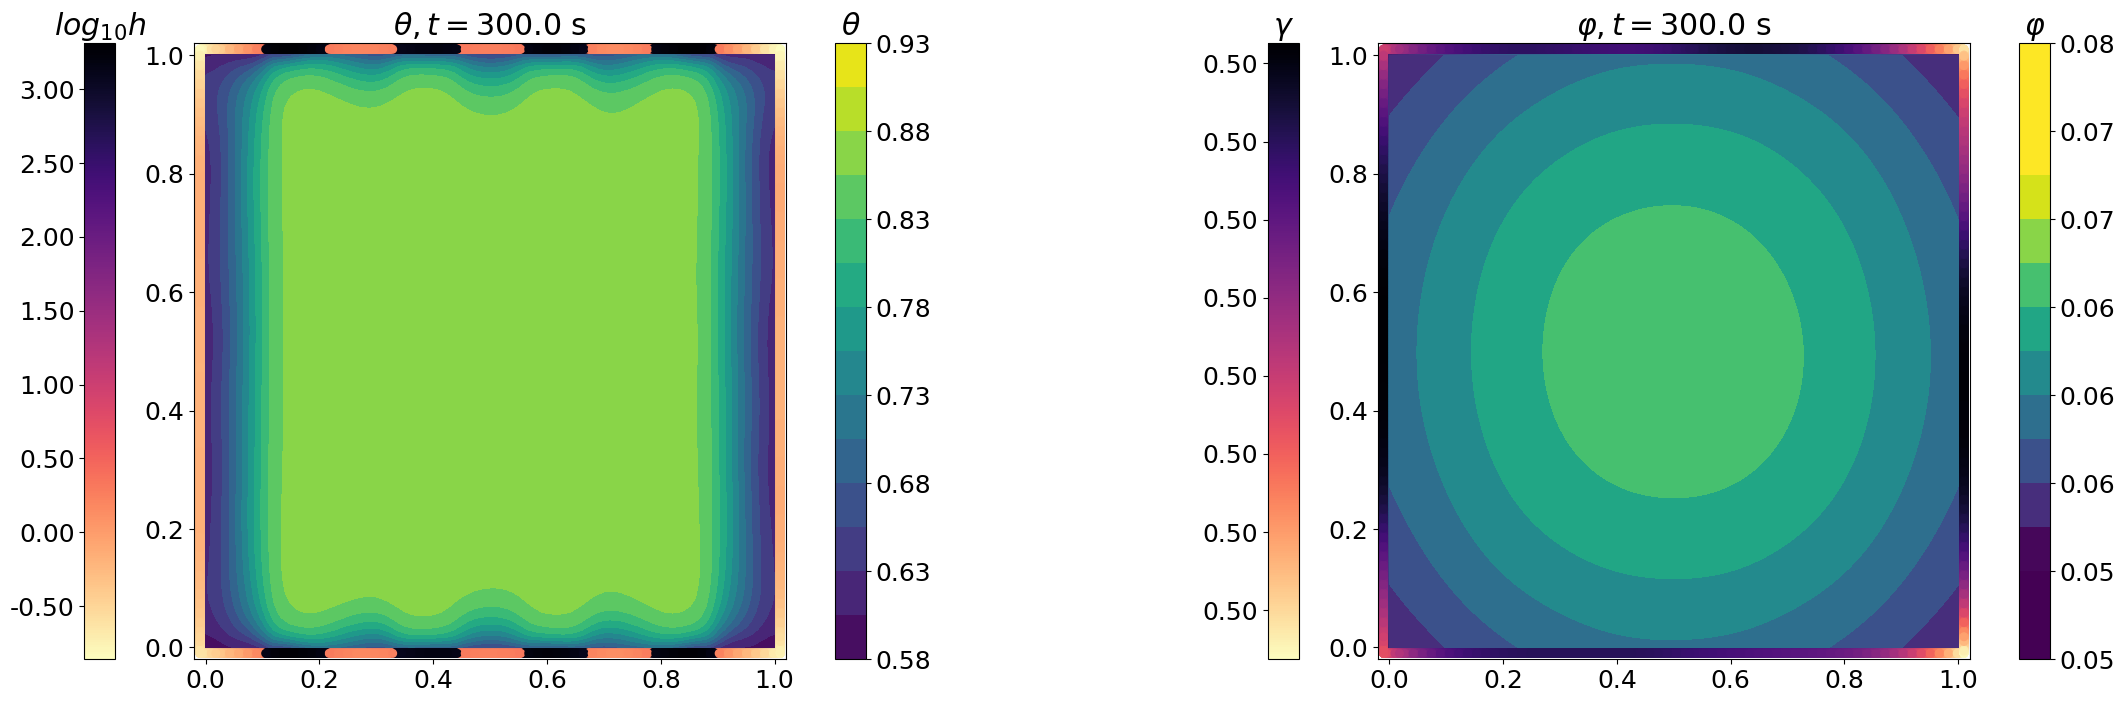

It: 1050 Time: 8.636082172393799 loss_w: 0.0124603659 loss: 0.00036038339 J 0.00340862316
It: 1100 Time: 6.914965629577637 loss_w: 0.0124757756 loss: 0.00036031226 J 0.00340688834
It: 1150 Time: 6.892326593399048 loss_w: 0.0124888364 loss: 0.000357468904 J 0.00342984451
It: 1200 Time: 6.848711967468262 loss_w: 0.0125521058 loss: 0.000368189183 J 0.00343874656
It: 1250 Time: 6.895609617233276 loss_w: 0.0125703774 loss: 0.000363679137 J 0.00344885373
It: 1300 Time: 7.522184610366821 loss_w: 0.0125852041 loss: 0.000363603642 J 0.00345925288
It: 1350 Time: 6.943897008895874 loss_w: 0.0126405824 loss: 0.000368278386 J 0.00348846056
It: 1400 Time: 5.925713539123535 loss_w: 0.01385184 loss: 0.00064359419 J 0.00347489747
It: 1450 Time: 5.88915491104126 loss_w: 0.0128039867 loss: 0.000389358116 J 0.00350423297
It: 1500 Time: 5.854296922683716 loss_w: 0.0126294624 loss: 0.000356944103 J 0.00352051063
It: 1550 Time: 5.642784595489502 loss_w: 0.0126739526 loss: 0.000363558 J 0.00351993856
It: 1600

<Figure size 640x480 with 0 Axes>

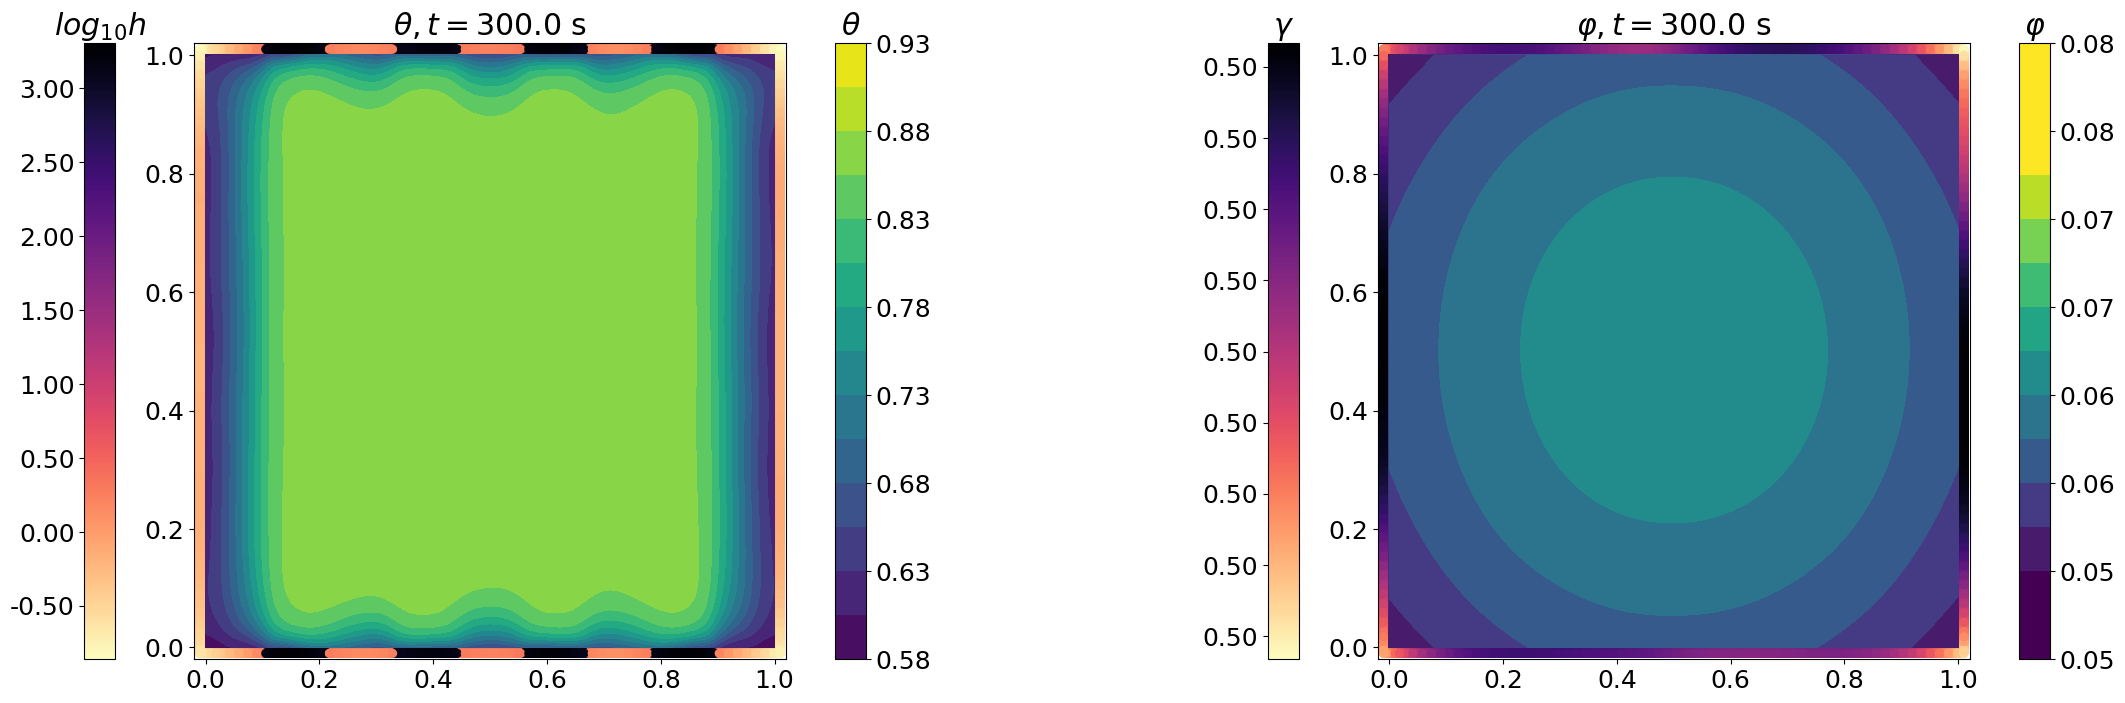

It: 2050 Time: 7.864450693130493 loss_w: 0.0134649174 loss: 0.00045063303 J 0.00364060025
It: 2100 Time: 5.4383580684661865 loss_w: 0.0130956713 loss: 0.000399019744 J 0.00364694884


KeyboardInterrupt: 

In [26]:
train.fit(10000)

<Figure size 640x480 with 0 Axes>

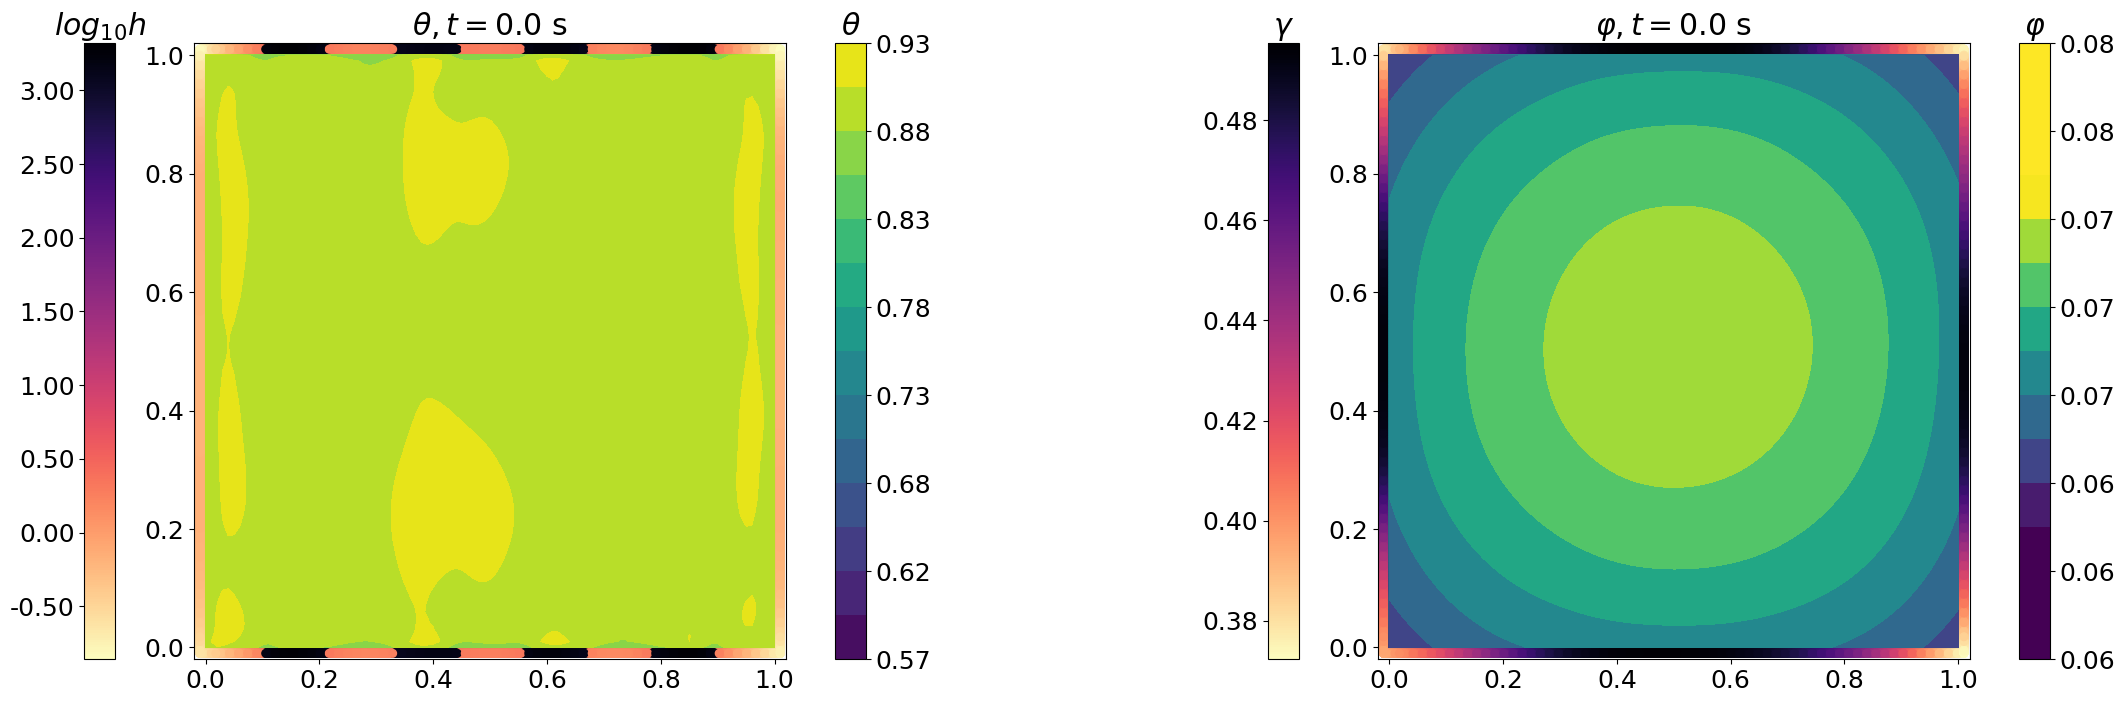

In [25]:
vis.plotu(0.0)

In [ ]:
vis.plotu(0.03)

In [ ]:
plt.scatter(X_b[:,0:1],X_b[:,1:2],c=HH)
plt.colorbar()

In [ ]:
vis.plotu()

In [ ]:
vis.plotu(10.0)

In [ ]:
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111)
ax.semilogy(range(len(train.hist1)),train.hist1,label='$L_w$')
ax.semilogy(range(len(train.hist2)),train.hist2, label = '$L$')
ax.semilogy(range(len(train.hist32)),train.hist32, label='$J_{obs}$')
plt.xlabel('epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

In [ ]:
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111)

ax.semilogy(range(len(histdefault[0:30000])), histdefault[0:30000],'k-',color='darkblue',linewidth=3.0,label='Nondimensional variables with isotropic FFE EPINN')
ax.semilogy(range(len(histisotropic[0:30000])), histisotropic[0:30000],'k-',color='darkred',linewidth=3.0,label='Isotropic FFE EPINN')
ax.semilogy(range(len(histanisotropic[0:30000])), histanisotropic[0:30000],'k-',color='darkgreen',linewidth=3.0,label='Anisotropic FFE EPINN')
ax.set_ylim(1e-5,1e5)
ax.set_xlabel('Epochs')
ax.set_ylabel('$J$');
ax.set_xlim(-500,15500)
ax.set_xticks([0,3000,6000,9000,12000,15000])
ax.grid()
ax.legend()
#plt.savefig('histfwd6.png', bbox_inches='tight', dpi=300)

In [ ]:
PINN.models[0].save(f"modeltheta")
PINN.models[1].save(f"modelphi")
PINN.models[2].save(f"modelh")
PINN.models[3].save(f"modelgamma")

In [ ]:
modeltheta = tf.keras.models.load_model(f"modeltheta")
modelphi   = tf.keras.models.load_model(f"modelphi")
modelh     = tf.keras.models.load_model(f"modelh")
modelgamma = tf.keras.models.load_model(f"modelgamma")



In [ ]:
modeltheta(gen.X_data[0])

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(gen.X_data[0][:,0:1],gen.X_data[0][:,1:2],s=2,label='Collocation points')
plt.scatter(gen.X_data[1][:,0:1],gen.X_data[1][:,1:2],s=3,color='red',label='Boundary points')
plt.scatter(gen.X_data[3][:,0:1],gen.X_data[3][:,1:2],color='black',marker='X',s=50,label='Observation points')
plt.legend()
plt.show()

In [ ]:
path